# Retrieval Evaluation — CDC Diabetes Prevention RAG

This notebook analyzes retrieval outputs from `evaluator.py`.

It compares:
- BM25
- Dense retrieval
- Hybrid RRF
- Hybrid RRF + CrossEncoder reranking

Retrieval is evaluated in two complementary ways:

1. **Known-reference evaluation** — Recall and MRR measure whether retrieval recovers the human-selected reference document, page, and chunk.
2. **Pooled graded-relevance evaluation** — retrieved CDC documents are judged as:
   - **2** — directly relevant
   - **1** — partially relevant / useful background
   - **0** — not relevant

The graded judgments are used to evaluate additional medically valid evidence, including nDCG.


## 1. Setup
Expected files:
- `evaluation/questions.json`
- `evaluation/retrieval_results.json`


In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "evaluation":
    PROJECT_ROOT = PROJECT_ROOT.parent

EVALUATION_DIR = PROJECT_ROOT / "evaluation"
RESULTS_FILE = EVALUATION_DIR / "retrieval_results.json"
JUDGMENTS_FILE = EVALUATION_DIR / "relevance_judgments.json"

print("Project root:", PROJECT_ROOT)
print("Results file:", RESULTS_FILE)

Project root: c:\Users\gokif\projects\cdc_diabetes_rag
Results file: c:\Users\gokif\projects\cdc_diabetes_rag\evaluation\retrieval_results.json


## 2. Load retrieval results


In [2]:
with open(RESULTS_FILE, "r", encoding = "utf-8") as f:
    retrieval_data = json.load(f)

results = retrieval_data["results"]
metadata = retrieval_data["evaluation"]

print("Questions:", metadata["question_count"])
print("Chunks:", metadata["chunk_count"])
print("Methods:", metadata["methods"])

Questions: 20
Chunks: 3154
Methods: ['bm25', 'dense', 'hybrid', 'hybrid_reranked']


## 3. Convert results to a table


In [3]:
rows = []

for qr in results:
    for method, retrieved in qr["retrieval"].items():
        for item in retrieved:
            rows.append({
                "question_id": qr["id"],
                "category": qr.get("category", ""),
                "question": qr["question"],
                "method": method,
                "rank": item.get("rank"),
                "chunk_id": item.get("chunk_id"),
                "cdc_id": str(item.get("cdc_id")) if item.get("cdc_id") is not None else None,
                "title": item.get("title"),
                "page": item.get("page"),
                "bm25_score": item.get("bm25_score"),
                "dense_score": item.get("dense_score"),
                "rrf_score": item.get("rrf_score"),
                "reranker_score": item.get("reranker_score"),
                "text": item.get("text"),
                "landing_page": item.get("landing_page"),
            })

retrieval_df = pd.DataFrame(rows)
print("Rows:", len(retrieval_df))
retrieval_df.head()

Rows: 800


,question_id,category,question,method,rank,chunk_id,cdc_id,title,page,bm25_score,dense_score,rrf_score,reranker_score,text,landing_page
0,Q01,,How was giving birth to a macrosomic infant as...,bm25,1,cdc_21008_p6_c3,21008,"Gestational Age, Infant Birth Weight, and Subs...",6,46.545969,NaN,NaN,NaN,veloping T2DM over the 35-year follow-up perio...,https://stacks.cdc.gov/view/cdc/21008
1,Q01,,How was giving birth to a macrosomic infant as...,bm25,2,cdc_21008_p1_c1,21008,"Gestational Age, Infant Birth Weight, and Subs...",1,41.538659,NaN,NaN,NaN,"Volume 10 — September 19, 2013\nORIGINAL RESEA...",https://stacks.cdc.gov/view/cdc/21008
2,Q01,,How was giving birth to a macrosomic infant as...,bm25,3,cdc_21008_p1_c2,21008,"Gestational Age, Infant Birth Weight, and Subs...",1,41.124863,NaN,NaN,NaN,"tterm birth, low \nbirth weight, and macrosomi...",https://stacks.cdc.gov/view/cdc/21008
3,Q01,,How was giving birth to a macrosomic infant as...,bm25,4,cdc_21008_p4_c5,21008,"Gestational Age, Infant Birth Weight, and Subs...",4,40.163665,NaN,NaN,NaN,nd T2DM in 5-year intervals following first pr...,https://stacks.cdc.gov/view/cdc/21008
4,Q01,,How was giving birth to a macrosomic infant as...,bm25,5,cdc_21008_p5_c2,21008,"Gestational Age, Infant Birth Weight, and Subs...",5,40.149325,NaN,NaN,NaN,ht was not associated with T2DM in the overall...,https://stacks.cdc.gov/view/cdc/21008


## 4. Ground-truth retrieval evaluation

This section evaluates retrieval performance against the human-selected reference evidence in `reference_answers.json`.

Each benchmark question has one human-selected reference source with:

- CDC document ID
- reference page
- reference chunk

Retrieval is evaluated at three levels:

- **Document level** — whether the correct CDC article was retrieved
- **Page level** — whether the correct CDC article and reference page were retrieved
- **Chunk level** — whether the exact reference chunk was retrieved

The reference evidence was selected independently before retrieval evaluation.

This benchmark does not assume that other retrieved CDC documents are irrelevant. Human relevance judgments can later be used to evaluate additional valid evidence.

In [4]:
REFERENCE_FILE = EVALUATION_DIR / "reference_answers.json"

with open(REFERENCE_FILE, "r", encoding = "utf-8") as f:
    reference_data = json.load(f)

references = {
    item["id"]: item
    for item in reference_data["items"]
}

print("Retrieval questions:", len(results))
print("Reference questions:", len(references))
print("Reference file:", REFERENCE_FILE)

Retrieval questions: 20
Reference questions: 20
Reference file: c:\Users\gokif\projects\cdc_diabetes_rag\evaluation\reference_answers.json


### Reference matching functions

The following functions compare retrieved chunks with the human-selected reference source.

A document match requires the same CDC ID.

A page match requires both the same CDC ID and the same PDF page.

A chunk match requires the exact benchmark `chunk_id`.

In [5]:
METHODS = [
    "bm25",
    "dense",
    "hybrid",
    "hybrid_reranked",
]

K_VALUES = [1, 3, 5, 10]


def get_reference(question_id):
    source = references[question_id]["reference_source"]

    return {
        "cdc_id": str(source["cdc_id"]),
        "page": source["page"],
        "chunk_id": source["chunk_id"],
    }


def document_match(result, reference):
    return (
        str(result.get("cdc_id"))
        == reference["cdc_id"]
    )


def page_match(result, reference):
    return (
        str(result.get("cdc_id"))
        == reference["cdc_id"]
        and result.get("page") == reference["page"]
    )


def chunk_match(result, reference):
    return (
        result.get("chunk_id")
        == reference["chunk_id"]
    )

### Per-question benchmark ranks and Recall@k

For each question and retrieval method, this cell identifies the first rank at which the human-selected reference document, page, and exact chunk appear.

Recall@k is binary for this benchmark because each question currently has one selected reference target at each evaluation level.

In [6]:
def first_relevant_rank(items, reference, match_function):
    for rank, item in enumerate(items, start=1):
        if match_function(item, reference):
            return rank

    return None


def benchmark_recall_at_k(
    items,
    reference,
    match_function,
    k,
):
    return int(
        any(
            match_function(item, reference)
            for item in items[:k]
        )
    )


benchmark_rows = []

for question_result in results:
    question_id = question_result["id"]
    reference = get_reference(question_id)

    retrieval = question_result["retrieval"]

    for method in METHODS:
        items = retrieval.get(method, [])

        document_rank = first_relevant_rank(
            items,
            reference,
            document_match,
        )

        page_rank = first_relevant_rank(
            items,
            reference,
            page_match,
        )

        chunk_rank = first_relevant_rank(
            items,
            reference,
            chunk_match,
        )

        row = {
            "question_id": question_id,
            "method": method,
            "document_rank": document_rank,
            "page_rank": page_rank,
            "chunk_rank": chunk_rank,
        }

        for k in K_VALUES:
            row[f"document_recall@{k}"] = (
                benchmark_recall_at_k(
                    items,
                    reference,
                    document_match,
                    k,
                )
            )

            row[f"page_recall@{k}"] = (
                benchmark_recall_at_k(
                    items,
                    reference,
                    page_match,
                    k,
                )
            )

            row[f"chunk_recall@{k}"] = (
                benchmark_recall_at_k(
                    items,
                    reference,
                    chunk_match,
                    k,
                )
            )

        benchmark_rows.append(row)

benchmark_df = pd.DataFrame(benchmark_rows)

benchmark_df.head(12)

,question_id,method,document_rank,page_rank,chunk_rank,document_recall@1,page_recall@1,chunk_recall@1,document_recall@3,page_recall@3,chunk_recall@3,document_recall@5,page_recall@5,chunk_recall@5,document_recall@10,page_recall@10,chunk_recall@10
0,Q01,bm25,1.0,5.0,5.0,1,0,0,1,0,0,1,1,1,1,1,1
1,Q01,dense,1.0,5.0,NaN,1,0,0,1,0,0,1,1,0,1,1,0
2,Q01,hybrid,1.0,7.0,8.0,1,0,0,1,0,0,1,0,0,1,1,1
3,Q01,hybrid_reranked,1.0,2.0,8.0,1,0,0,1,1,0,1,1,0,1,1,1
4,Q02,bm25,1.0,1.0,1.0,1,1,1,1,1,1,1,1,1,1,1,1
5,Q02,dense,1.0,6.0,6.0,1,0,0,1,0,0,1,0,0,1,1,1
6,Q02,hybrid,1.0,2.0,2.0,1,0,0,1,1,1,1,1,1,1,1,1
7,Q02,hybrid_reranked,1.0,1.0,1.0,1,1,1,1,1,1,1,1,1,1,1,1
8,Q03,bm25,1.0,1.0,1.0,1,1,1,1,1,1,1,1,1,1,1,1
9,Q03,dense,1.0,3.0,3.0,1,0,0,1,1,1,1,1,1,1,1,1


### Aggregate benchmark metrics

Mean Reciprocal Rank (MRR) measures how highly the selected reference first appears.

Recall@k measures the proportion of the 20 benchmark questions for which the selected reference appears within the top *k* retrieved results.

Metrics are reported separately for:

- document retrieval
- exact reference-page retrieval
- exact reference-chunk retrieval

In [7]:
benchmark_summary_rows = []

for method in METHODS:
    method_df = benchmark_df[
        benchmark_df["method"] == method
    ]

    summary = {
        "method": method
    }

    for level in [
        "document",
        "page",
        "chunk",
    ]:
        rank_column = f"{level}_rank"

        reciprocal_ranks = [
            1 / rank if pd.notna(rank) else 0
            for rank in method_df[rank_column]
        ]

        summary[f"{level}_MRR"] = (
            sum(reciprocal_ranks)
            / len(reciprocal_ranks)
        )

        for k in K_VALUES:
            summary[f"{level}_R@{k}"] = (
                method_df[
                    f"{level}_recall@{k}"
                ].mean()
            )

    benchmark_summary_rows.append(summary)

benchmark_summary_df = pd.DataFrame(
    benchmark_summary_rows
)

benchmark_summary_df.round(3)

,method,document_MRR,document_R@1,document_R@3,document_R@5,document_R@10,page_MRR,page_R@1,page_R@3,page_R@5,page_R@10,chunk_MRR,chunk_R@1,chunk_R@3,chunk_R@5,chunk_R@10
0,bm25,0.881,0.85,0.9,0.90,0.95,0.671,0.55,0.75,0.80,0.90,0.611,0.5,0.65,0.75,0.85
1,dense,0.879,0.85,0.9,0.95,0.95,0.451,0.35,0.45,0.65,0.75,0.327,0.2,0.40,0.55,0.60
2,hybrid,0.849,0.80,0.9,0.90,0.95,0.534,0.40,0.60,0.70,0.85,0.495,0.4,0.55,0.65,0.70
3,hybrid_reranked,0.882,0.85,0.9,0.90,0.95,0.611,0.50,0.70,0.75,0.85,0.511,0.4,0.60,0.70,0.80


### Main benchmark comparison

This table provides the main retrieval comparison across BM25, dense retrieval, hybrid RRF, and hybrid RRF with CrossEncoder reranking.

In [8]:
benchmark_display_columns = [
    "method",

    "document_MRR",
    "document_R@1",
    "document_R@3",
    "document_R@5",
    "document_R@10",

    "page_MRR",
    "page_R@1",
    "page_R@3",
    "page_R@5",
    "page_R@10",

    "chunk_MRR",
    "chunk_R@1",
    "chunk_R@3",
    "chunk_R@5",
    "chunk_R@10",
]

benchmark_summary_df[
    benchmark_display_columns
].round(3)

,method,document_MRR,document_R@1,document_R@3,document_R@5,document_R@10,page_MRR,page_R@1,page_R@3,page_R@5,page_R@10,chunk_MRR,chunk_R@1,chunk_R@3,chunk_R@5,chunk_R@10
0,bm25,0.881,0.85,0.9,0.90,0.95,0.671,0.55,0.75,0.80,0.90,0.611,0.5,0.65,0.75,0.85
1,dense,0.879,0.85,0.9,0.95,0.95,0.451,0.35,0.45,0.65,0.75,0.327,0.2,0.40,0.55,0.60
2,hybrid,0.849,0.80,0.9,0.90,0.95,0.534,0.40,0.60,0.70,0.85,0.495,0.4,0.55,0.65,0.70
3,hybrid_reranked,0.882,0.85,0.9,0.90,0.95,0.611,0.50,0.70,0.75,0.85,0.511,0.4,0.60,0.70,0.80


### Per-question reference ranks

This table helps identify retrieval failures.

A missing value means that the selected reference document, page, or chunk was not retrieved within the stored result depth for that method.

In [9]:
benchmark_rank_table = (
    benchmark_df[
        [
            "question_id",
            "method",
            "document_rank",
            "page_rank",
            "chunk_rank",
        ]
    ]
    .sort_values(
        ["question_id", "method"]
    )
    .reset_index(drop=True)
)

benchmark_rank_table

,question_id,method,document_rank,page_rank,chunk_rank
0,Q01,bm25,1.0,5.0,5.0
1,Q01,dense,1.0,5.0,NaN
2,Q01,hybrid,1.0,7.0,8.0
3,Q01,hybrid_reranked,1.0,2.0,8.0
4,Q02,bm25,1.0,1.0,1.0
...,...,...,...,...,...
75,Q19,hybrid_reranked,1.0,3.0,3.0
76,Q20,bm25,1.0,1.0,1.0
77,Q20,dense,1.0,NaN,NaN
78,Q20,hybrid,1.0,6.0,NaN


## 5. Top-ranked result for every question and method


In [10]:
top1_df = (
    retrieval_df[retrieval_df["rank"] == 1]
    [["question_id", "method", "cdc_id", "page", "title"]]
    .sort_values(["question_id", "method"])
    .reset_index(drop = True)
)
top1_df

,question_id,method,cdc_id,page,title
0,Q01,bm25,21008,6,"Gestational Age, Infant Birth Weight, and Subs..."
1,Q01,dense,21008,1,"Gestational Age, Infant Birth Weight, and Subs..."
2,Q01,hybrid,21008,1,"Gestational Age, Infant Birth Weight, and Subs..."
3,Q01,hybrid_reranked,21008,1,"Gestational Age, Infant Birth Weight, and Subs..."
4,Q02,bm25,24402,3,Implementation and Outcomes of the New York St...
...,...,...,...,...,...
75,Q19,hybrid_reranked,151104,1,Public Belief in the Maternal Health Benefits ...
76,Q20,bm25,151112,4,Factors Influencing the Referral of Patients w...
77,Q20,dense,151112,8,Factors Influencing the Referral of Patients w...
78,Q20,hybrid,151112,5,Factors Influencing the Referral of Patients w...


## 6. Inspect one question

Change `QUESTION_ID` as needed. Q12 is useful because its rank-1 reranked result looked potentially weak.


In [11]:
QUESTION_ID = "Q12"

subset = retrieval_df[retrieval_df["question_id"] == QUESTION_ID].copy()
print(QUESTION_ID, "-", subset["question"].iloc[0])

display(
    subset[["method", "rank", "cdc_id", "page", "title"]]
    .sort_values(["method", "rank"])
)

Q12 - What is the role of Diabetes Self-Management Education and Support (DSMES), and when is it usually offered to people with diabetes?


,method,rank,cdc_id,page,title
440,bm25,1,52337,1,Implementing Key Drivers for Diabetes Self-Man...
441,bm25,2,52337,5,Implementing Key Drivers for Diabetes Self-Man...
442,bm25,3,52337,5,Implementing Key Drivers for Diabetes Self-Man...
443,bm25,4,52337,6,Implementing Key Drivers for Diabetes Self-Man...
444,bm25,5,52337,5,Implementing Key Drivers for Diabetes Self-Man...
445,bm25,6,20408,5,A Diabetes Self-Management Program Designed fo...
446,bm25,7,20255,10,"Living With Ma’i Suka: Individual, Familial, C..."
447,bm25,8,52337,2,Implementing Key Drivers for Diabetes Self-Man...
448,bm25,9,4161,10,"The Culture, Community, and Science of Type 2 ..."
449,bm25,10,20408,5,A Diabetes Self-Management Program Designed fo...


## 7. Inspect actual chunk text


In [12]:
def show_results(question_id, method="hybrid_reranked", top_k = 10):
    subset = retrieval_df[
        (retrieval_df["question_id"] == question_id)
        & (retrieval_df["method"] == method)
        & (retrieval_df["rank"] <= top_k)
    ].sort_values("rank")

    print(f"{question_id}: {subset['question'].iloc[0]}\n")

    for _, row in subset.iterrows():
        print("=" * 90)
        print(f"Rank {int(row['rank'])} | CDC {row['cdc_id']} | Page {row['page']} | {row['title']}")
        print("-" * 90)
        print((row["text"] or "")[:1800])
        print()

show_results("Q12", "hybrid_reranked", 10)

Q12: What is the role of Diabetes Self-Management Education and Support (DSMES), and when is it usually offered to people with diabetes?

Rank 1 | CDC 52337 | Page 1 | Implementing Key Drivers for Diabetes Self-Management Education and Support Programs: Early Outcomes, Activities, Facilitators, and Barriers
------------------------------------------------------------------------------------------
3 years of activity of the cooperative agreement.
Clinical and Community Linkages To
Support Diabetes Self-Management
One way to improve diabetes management is to increase linkages
between community resources and clinical services. Diabetes self-
management education and support (DSMES) programs connect
people with diabetes to effective clinical services in their com-
munities. DSMES is usually offered to patients at diagnosis, dur-
ing annual assessments, and when transitions or new disease com-
plications occur that influence self-management and is guided by
evidence-based standards. DSMES i

## 8. Human relevance judgments for pooled retrieval candidates

The benchmark above evaluates retrieval against one human-selected reference passage for each question. However, a medical-literature question may have multiple relevant CDC documents or passages.

To evaluate these alternative results, this section creates a pooled set of candidates retrieved by BM25, dense retrieval, hybrid retrieval, and CrossEncoder reranking.

Each unique CDC document retrieved for a question is judged manually using the following scale:

- **0 — Not relevant:** does not provide useful evidence for answering the question.
- **1 — Partially relevant:** provides useful background or indirect evidence, but does not directly answer the question.
- **2 — Directly relevant:** provides evidence that directly helps answer the question.

The preselected benchmark reference remains the known evidence anchor. These additional judgments are used to evaluate whether the retrieval system finds other medically valid evidence that is not represented by the single benchmark reference.


In [13]:
JUDGMENTS_FILE = EVALUATION_DIR / "relevance_judgments.json"

POOL_DEPTH = 5

candidate_rows = []

for question_result in results:
    question_id = question_result["id"]
    question = question_result["question"]
    reference = get_reference(question_id)

    pooled_documents = {}

    for method in METHODS:
        retrieved = question_result["retrieval"].get(
            method, []
        )

        for rank, item in enumerate(
            retrieved[:POOL_DEPTH],
            start=1,
        ):
            cdc_id = str(item.get("cdc_id"))

            if cdc_id not in pooled_documents:
                is_reference = (
                    cdc_id == reference["cdc_id"]
                )

                pooled_documents[cdc_id] = {
                    "question_id": question_id,
                    "question": question,
                    "cdc_id": cdc_id,
                    "title": item.get("title"),
                    "pages": set(),
                    "chunk_ids": set(),
                    "retrieved_by": set(),
                    "evidence_passages": {},
                    "known_reference_document": is_reference,

                    # The selected reference document is
                    # already known to be directly relevant.
                    "relevance": 2 if is_reference else None,

                    "notes": (
                        "Human-selected benchmark reference document."
                        if is_reference
                        else ""
                    ),
                }

            candidate = pooled_documents[cdc_id]

            page = item.get("page")
            chunk_id = item.get("chunk_id")

            if page is not None:
                candidate["pages"].add(page)

            if chunk_id:
                candidate["chunk_ids"].add(chunk_id)

            candidate["retrieved_by"].add(method)

            if chunk_id not in candidate["evidence_passages"]:
                candidate["evidence_passages"][chunk_id] = {
                    "chunk_id": chunk_id,
                    "page": page,
                    "text": item.get("text", ""),
                    "retrieved_by": set(),
                    "best_rank": rank,
                }

            passage = candidate["evidence_passages"][chunk_id]

            passage["retrieved_by"].add(method)

            passage["best_rank"] = min(
                passage["best_rank"],
                rank,
            )

    for candidate in pooled_documents.values():
        candidate["pages"] = sorted(
            candidate["pages"]
        )

        candidate["chunk_ids"] = sorted(
            candidate["chunk_ids"]
        )

        candidate["retrieved_by"] = sorted(
            candidate["retrieved_by"]
        )

        passages = []

        for passage in candidate[
            "evidence_passages"
        ].values():

            passage["retrieved_by"] = sorted(
                passage["retrieved_by"]
            )

            passages.append(passage)

        passages.sort(
            key=lambda x: (
                x["best_rank"],
                x["page"] if x["page"] is not None else 9999,
            )
        )

        candidate["evidence_passages"] = passages

        candidate_rows.append(candidate)

print(
    "Pooled question-document pairs:",
    len(candidate_rows),
)

Pooled question-document pairs: 68


In [14]:
with open(
    JUDGMENTS_FILE,
    "w",
    encoding = "utf-8",
) as f:
    json.dump(
        candidate_rows,
        f,
        ensure_ascii = False,
        indent = 2,
    )

print("Saved:", JUDGMENTS_FILE)

known_reference_count = sum(
    row["known_reference_document"]
    for row in candidate_rows
)

pending_count = sum(
    row["relevance"] is None
    for row in candidate_rows
)

print(
    "Known reference documents:",
    known_reference_count,
)

print(
    "Automatically assigned relevance=2:",
    known_reference_count,
)

print(
    "Manual judgments remaining:",
    pending_count,
)

Saved: c:\Users\gokif\projects\cdc_diabetes_rag\evaluation\relevance_judgments.json
Known reference documents: 19
Automatically assigned relevance=2: 19
Manual judgments remaining: 49


In [15]:
judgment_df = pd.DataFrame(candidate_rows)

judgment_df[
    [
        "question_id",
        "cdc_id",
        "title",
        "pages",
        "retrieved_by",
        "known_reference_document",
        "relevance",
    ]
].head(20)

,question_id,cdc_id,title,pages,retrieved_by,known_reference_document,relevance
0,Q01,21008,"Gestational Age, Infant Birth Weight, and Subs...","[1, 2, 4, 5, 6, 10]","[bm25, dense, hybrid, hybrid_reranked]",True,2.0
1,Q02,24402,Implementation and Outcomes of the New York St...,"[1, 2, 3, 4, 6, 7]","[bm25, dense, hybrid, hybrid_reranked]",True,2.0
2,Q02,50304,"Early Results of States’ Efforts to Support, S...","[4, 7]","[bm25, hybrid_reranked]",False,NaN
3,Q02,20117,Mexican Americans With Type 2 Diabetes: Perspe...,[8],[dense],False,NaN
4,Q02,4095,A Six-Step Model for Evaluation of Community-b...,[6],[dense],False,NaN
5,Q02,150995,“Make Stories That Will Always Be There”: Eagl...,[15],[dense],False,NaN
6,Q03,26402,Ohio Primary Health Care Providers’ Practices ...,"[1, 3, 4, 6]","[bm25, dense, hybrid, hybrid_reranked]",True,2.0
7,Q03,21008,"Gestational Age, Infant Birth Weight, and Subs...",[2],"[bm25, hybrid_reranked]",False,NaN
8,Q04,26740,Factors Associated With Daily Consumption of S...,"[1, 5, 8, 10, 11, 12, 15]","[bm25, dense, hybrid, hybrid_reranked]",True,2.0
9,Q05,19766,Missed Opportunities for Providing Low-Fat Die...,"[2, 4]","[bm25, dense, hybrid, hybrid_reranked]",False,NaN


In [16]:
pending_rows = []

for row in candidate_rows:
    if row["relevance"] is not None:
        continue

    passages = row["evidence_passages"]

    # Show up to the three highest-ranked retrieved passages
    best_passages = passages[:3]

    evidence_preview = "\n\n".join(
        [
            (
                f"Page {p['page']} | "
                f"best rank {p['best_rank']} | "
                f"methods: {', '.join(p['retrieved_by'])}\n"
                f"{p['text']}"
            )
            for p in best_passages
        ]
    )

    pending_rows.append(
        {
            "question_id": row["question_id"],
            "question": row["question"],
            "cdc_id": row["cdc_id"],
            "title": row["title"],
            "pages": row["pages"],
            "evidence_preview": evidence_preview,
            "relevance": None,
            "notes": "",
        }
    )

pending_review_df = pd.DataFrame(pending_rows)

print("Pending manual judgments:", len(pending_review_df))

pending_review_df.head(10)

Pending manual judgments: 49


,question_id,question,cdc_id,title,pages,evidence_preview,relevance,notes
0,Q02,What were the most commonly reported motivatio...,50304,"Early Results of States’ Efforts to Support, S...","[4, 7]",Page 4 | best rank 5 | methods: hybrid_reranke...,None,
1,Q02,What were the most commonly reported motivatio...,20117,Mexican Americans With Type 2 Diabetes: Perspe...,[8],Page 8 | best rank 3 | methods: dense\nention ...,None,
2,Q02,What were the most commonly reported motivatio...,4095,A Six-Step Model for Evaluation of Community-b...,[6],Page 6 | best rank 4 | methods: dense\nVOLUME ...,None,
3,Q02,What were the most commonly reported motivatio...,150995,“Make Stories That Will Always Be There”: Eagl...,[15],Page 15 | best rank 5 | methods: dense\ne ridi...,None,
4,Q03,Why is early ascertainment of a woman's histor...,21008,"Gestational Age, Infant Birth Weight, and Subs...",[2],"Page 2 | best rank 2 | methods: bm25, hybrid_r...",None,
5,Q05,Was greater diabetes-related knowledge associa...,19766,Missed Opportunities for Providing Low-Fat Die...,"[2, 4]","Page 4 | best rank 1 | methods: bm25, dense, h...",None,
6,Q05,Was greater diabetes-related knowledge associa...,49460,"Using Geographical Convergence of Obesity, Car...",[5],Page 5 | best rank 5 | methods: hybrid\nAs sup...,None,
7,Q06,What lifestyle changes associated with economi...,20255,"Living With Ma’i Suka: Individual, Familial, C...","[1, 2, 5, 7]","Page 2 | best rank 1 | methods: bm25, dense, h...",None,
8,Q06,What lifestyle changes associated with economi...,113215,Type 2 Diabetes Among Filipino American Adults...,[5],Page 5 | best rank 5 | methods: hybrid_reranke...,None,
9,Q07,How did weight-loss success in the worksite DP...,19628,Designing a Natural Experiment to Evaluate a N...,[1],"Page 1 | best rank 2 | methods: bm25, dense, h...",None,


In [17]:
REVIEW_CSV = EVALUATION_DIR / "relevance_judgments_review.csv"

pending_review_df.to_csv(
    REVIEW_CSV,
    index = False,
    encoding = "utf-8-sig",
)

print("Saved review CSV:", REVIEW_CSV)

Saved review CSV: c:\Users\gokif\projects\cdc_diabetes_rag\evaluation\relevance_judgments_review.csv


### Save `relevance_judgments.json`

This cell will not overwrite an existing judgment file.


In [18]:
if not JUDGMENTS_FILE.exists():
    with open(JUDGMENTS_FILE, "w", encoding = "utf-8") as f:
        json.dump(candidate_rows.to_dict(orient = "records"), f, indent = 2, ensure_ascii = False)
    print("Created:", JUDGMENTS_FILE)
else:
    print("Existing file preserved:", JUDGMENTS_FILE)

Existing file preserved: c:\Users\gokif\projects\cdc_diabetes_rag\evaluation\relevance_judgments.json


### Load completed human relevance judgments

The manually reviewed relevance judgments are stored separately in
`relevance_judgments_review_filled.csv` to prevent them from being overwritten
when the candidate review CSV is regenerated.

This file contains the completed relevance scores:
- **2** — directly relevant
- **1** — partially relevant / useful background
- **0** — not relevant

The following cell loads this protected review file for merging into
`relevance_judgments.json`.

In [19]:
REVIEW_CSV = EVALUATION_DIR / "relevance_judgments_review_filled.csv"

review_df = pd.read_csv(REVIEW_CSV, encoding = "utf-8-sig")

# Validate completed judgments
if review_df["relevance"].isna().any():
    raise ValueError(
        f"{review_df['relevance'].isna().sum()} relevance judgments are still missing."
    )

review_df["relevance"] = review_df["relevance"].astype(int)

invalid = review_df[~review_df["relevance"].isin([0, 1, 2])]
if not invalid.empty:
    raise ValueError("Relevance must be 0, 1, or 2.")

# Build lookup table from the completed review CSV
review_lookup = {
    (str(row.question_id), str(row.cdc_id)): (
        int(row.relevance),
        "" if pd.isna(row.notes) else str(row.notes)
    )
    for row in review_df.itertuples(index = False)
}

# Load pooled judgments
with open(JUDGMENTS_FILE, "r", encoding = "utf-8") as f:
    judgments = json.load(f)

# Merge the 49 manually reviewed judgments
updated = 0

for row in judgments:
    key = (str(row["question_id"]), str(row["cdc_id"]))

    if key in review_lookup:
        score, notes = review_lookup[key]
        row["relevance"] = score
        row["notes"] = notes
        updated += 1

# Save completed judgment set
with open(JUDGMENTS_FILE, "w", encoding="utf-8") as f:
    json.dump(judgments, f, ensure_ascii=False, indent = 2)

print("Updated manual judgments:", updated)
print("Total judgments:", len(judgments))
print(
    "Missing:",
    sum(row["relevance"] is None for row in judgments)
)

Updated manual judgments: 49
Total judgments: 68
Missing: 0


## 9. Load completed graded relevance judgments

The pooled retrieval candidates have been reviewed using three relevance levels:

- **2** — directly relevant
- **1** — partially relevant / useful background
- **0** — not relevant

The completed judgment set contains both the preselected reference documents and
additional relevant CDC documents identified through pooled retrieval.

All benchmark questions Q01–Q20 are included in this retrieval evaluation.


In [20]:
def load_judgments():
    if not JUDGMENTS_FILE.exists():
        return pd.DataFrame()

    with open(JUDGMENTS_FILE, "r", encoding = "utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(data)
    df["relevance"] = pd.to_numeric(df["relevance"], errors = "coerce")
    df["cdc_id"] = df["cdc_id"].astype(str)

    return df


judgments_df = load_judgments()

if judgments_df.empty:
    raise ValueError("No relevance judgments found.")

missing = judgments_df["relevance"].isna().sum()

print("Total judgments:", len(judgments_df))
print("Completed:", judgments_df["relevance"].notna().sum())
print("Missing:", missing)

if missing:
    raise ValueError(f"{missing} relevance judgments are incomplete.")

invalid = judgments_df[
    ~judgments_df["relevance"].isin([0, 1, 2])
]

if not invalid.empty:
    raise ValueError("Relevance judgments must be 0, 1, or 2.")

display(
    judgments_df["relevance"]
    .value_counts()
    .sort_index()
    .rename_axis("relevance")
    .to_frame("count")
)

Total judgments: 68
Completed: 68
Missing: 0


,count
relevance,
0,22
1,16
2,30


## 10. Metric functions


In [21]:
POOL_DEPTH = 5


def dcg(relevances):
    return sum(
        (2 ** rel - 1) / math.log2(rank + 1)
        for rank, rel in enumerate(relevances, start = 1)
    )


def ndcg_at_k(ranked_relevances, ideal_grades, k):
    actual = dcg(ranked_relevances[:k])
    ideal = dcg(sorted(ideal_grades, reverse = True)[:k])

    return actual / ideal if ideal > 0 else None


def reciprocal_rank(ranked_relevances):
    for rank, rel in enumerate(ranked_relevances, start = 1):
        if rel >= 1:
            return 1.0 / rank

    return 0.0


def recall_at_k(ranked_ids, relevant_ids, k):
    if not relevant_ids:
        return None

    retrieved_relevant = set(ranked_ids[:k]) & relevant_ids
    return len(retrieved_relevant) / len(relevant_ids)


def evaluate_method(
    question_id,
    method,
    judgments,
    rankings,
    k_values = (1, 3, 5),
):
    qj = judgments[
        (judgments["question_id"] == question_id)
        & judgments["relevance"].notna()
    ]

    relevance_by_id = {
        str(row["cdc_id"]): int(row["relevance"])
        for _, row in qj.iterrows()
    }

    # Relevance 1 or 2 counts as relevant for Recall/MRR.
    relevant_ids = {
        cdc_id
        for cdc_id, relevance in relevance_by_id.items()
        if relevance >= 1
    }

    # The human judgment pool was generated from top-5 retrieved chunks.
    # Restrict evaluation to that same judged cutoff before document deduplication.
    ranked = (
        rankings[
            (rankings["question_id"] == question_id)
            & (rankings["method"] == method)
            & (rankings["rank"] <= POOL_DEPTH)
        ]
        .sort_values("rank")
        .drop_duplicates("cdc_id", keep = "first")
    )

    ranked_ids = ranked["cdc_id"].astype(str).tolist()

    ranked_rels = [
        relevance_by_id.get(cdc_id, 0)
        for cdc_id in ranked_ids
    ]

    # Ideal ranking is based on all judged documents in the pooled candidate set.
    ideal_grades = list(relevance_by_id.values())

    out = {
        "question_id": question_id,
        "method": method,
        "MRR": reciprocal_rank(ranked_rels),
    }

    for k in k_values:
        out[f"Recall@{k}"] = recall_at_k(
            ranked_ids,
            relevant_ids,
            k,
        )

        out[f"nDCG@{k}"] = ndcg_at_k(
            ranked_rels,
            ideal_grades,
            k,
        )

    return out

## 11. Calculate per-question metrics for Q01–Q20


In [22]:
MAIN_QUESTIONS = [f"Q{i:02d}" for i in range(1, 21)]

METHODS = [
    "bm25",
    "dense",
    "hybrid",
    "hybrid_reranked",
]

rows = []

for qid in MAIN_QUESTIONS:
    for method in METHODS:
        rows.append(
            evaluate_method(
                qid,
                method,
                judgments_df,
                retrieval_df,
            )
        )

metrics_df = pd.DataFrame(rows)

print("Questions evaluated:", metrics_df["question_id"].nunique())
print("Method-question evaluations:", len(metrics_df))

display(metrics_df.head(20))

Questions evaluated: 20
Method-question evaluations: 80


,question_id,method,MRR,Recall@1,nDCG@1,Recall@3,nDCG@3,Recall@5,nDCG@5
0,Q01,bm25,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
1,Q01,dense,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,Q01,hybrid,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
3,Q01,hybrid_reranked,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
4,Q02,bm25,1.0,0.333333,1.0,0.666667,0.878962,0.666667,0.878962
5,Q02,dense,1.0,0.333333,1.0,0.666667,0.878962,0.666667,0.878962
6,Q02,hybrid,1.0,0.333333,1.0,0.333333,0.726229,0.333333,0.726229
7,Q02,hybrid_reranked,1.0,0.333333,1.0,0.666667,0.878962,0.666667,0.878962
8,Q03,bm25,1.0,0.500000,1.0,1.000000,1.000000,1.000000,1.000000
9,Q03,dense,1.0,0.500000,1.0,0.500000,0.826235,0.500000,0.826235


## 12. Aggregate method comparison


In [23]:
if metrics_df.empty:
    summary_df = pd.DataFrame()
    print("No metrics available yet.")
else:
    metric_cols = [c for c in metrics_df.columns if c not in {"question_id", "method"}]
    summary_df = (
        metrics_df.groupby("method")[metric_cols]
        .mean(numeric_only = True)
        .reindex(METHODS)
    )
    display(summary_df.round(4))

,MRR,Recall@1,nDCG@1,Recall@3,nDCG@3,Recall@5,nDCG@5
method,,,,,,,
bm25,0.9250,0.5446,0.90,0.7173,0.8509,0.7244,0.8361
dense,1.0000,0.6446,1.00,0.8173,0.9399,0.8440,0.9353
hybrid,0.9417,0.5446,0.90,0.7339,0.8489,0.7494,0.8373
hybrid_reranked,0.9750,0.5946,0.95,0.8173,0.9233,0.8452,0.9149


## 13. Recall@5


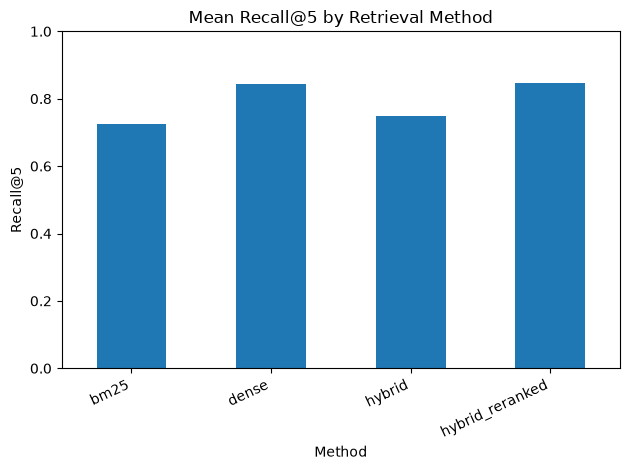

In [24]:
if not summary_df.empty:
    ax = summary_df["Recall@5"].plot(kind = "bar")
    ax.set_title("Mean Recall@5 by Retrieval Method")
    ax.set_xlabel("Method")
    ax.set_ylabel("Recall@5")
    ax.set_ylim(0, 1)
    plt.xticks(rotation = 25, ha = "right")
    plt.tight_layout()
    plt.show()

## 14. MRR


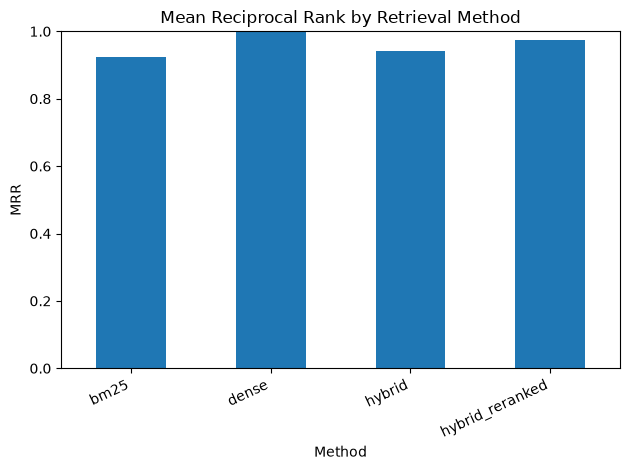

In [25]:
if not summary_df.empty:
    ax = summary_df["MRR"].plot(kind = "bar")
    ax.set_title("Mean Reciprocal Rank by Retrieval Method")
    ax.set_xlabel("Method")
    ax.set_ylabel("MRR")
    ax.set_ylim(0, 1)
    plt.xticks(rotation = 25, ha = "right")
    plt.tight_layout()
    plt.show()

## 15. nDCG@5


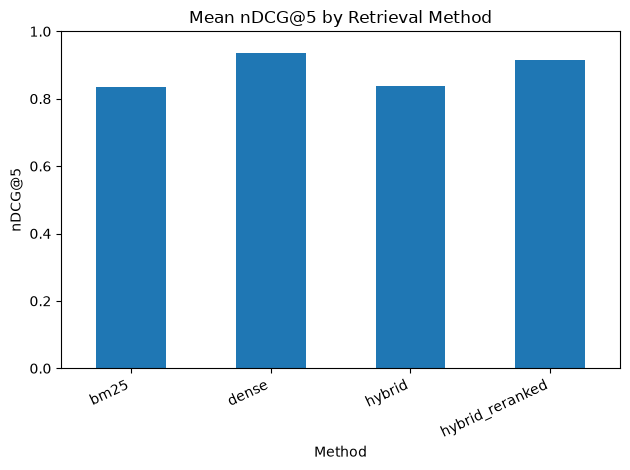

In [26]:
if not summary_df.empty:
    ax = summary_df["nDCG@5"].plot(kind = "bar")
    ax.set_title("Mean nDCG@5 by Retrieval Method")
    ax.set_xlabel("Method")
    ax.set_ylabel("nDCG@5")
    ax.set_ylim(0, 1)
    plt.xticks(rotation = 25, ha = "right")
    plt.tight_layout()
    plt.show()

## 16. Where does reranking help or hurt?


In [27]:
if not metrics_df.empty:
    pivot = metrics_df.pivot(index = "question_id", columns = "method", values = "nDCG@5")
    if {"hybrid", "hybrid_reranked"}.issubset(pivot.columns):
        pivot["reranker_delta"] = pivot["hybrid_reranked"] - pivot["hybrid"]
        display(pivot.sort_values("reranker_delta", ascending = False))

method,bm25,dense,hybrid,hybrid_reranked,reranker_delta
question_id,,,,,
Q05,0.630930,1.000000,0.630930,1.000000,0.369070
Q17,0.673293,0.556298,0.556298,0.907284,0.350985
Q12,0.657663,1.000000,0.657663,1.000000,0.342337
Q03,1.000000,0.826235,0.826235,1.000000,0.173765
Q13,0.826235,1.000000,0.826235,1.000000,0.173765
Q02,0.878962,0.878962,0.726229,0.878962,0.152733
Q08,0.000000,1.000000,0.500000,0.630930,0.130930
Q06,0.907284,0.907284,0.556298,0.673293,0.116995
Q15,0.747927,0.711609,0.771340,0.807657,0.036317


## 17. Interpretation

The retrieval system is evaluated from two complementary perspectives.

### Known-reference retrieval

The benchmark contains one human-selected reference passage for each question.
Document-, page-, and chunk-level Recall and MRR measure whether each retrieval
method can recover that known evidence anchor.

### Pooled graded relevance

Because multiple CDC documents may validly answer the same medical-literature
question, pooled candidates are additionally judged as:

- **2** — directly relevant
- **1** — partially relevant / useful background
- **0** — not relevant

These judgments support graded metrics such as nDCG and allow alternative valid
CDC evidence to receive credit rather than requiring retrieval of only the
preselected reference document.

The final retrieval architecture should therefore be assessed using:

1. known-reference document/page/chunk retrieval,
2. pooled graded relevance,
3. nDCG and graded Recall/MRR,
4. individual failure-case inspection,
5. reranker improvement or degradation,
6. latency and implementation cost.

Retrieval evaluation is followed separately by answer-level evaluation, where
generated answers are compared with the benchmark reference answers and checked
for correctness, completeness, evidence grounding, citation accuracy,
study-context fidelity, unsupported claims, and medical safety.
